In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt

from src.d_CSL import *

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


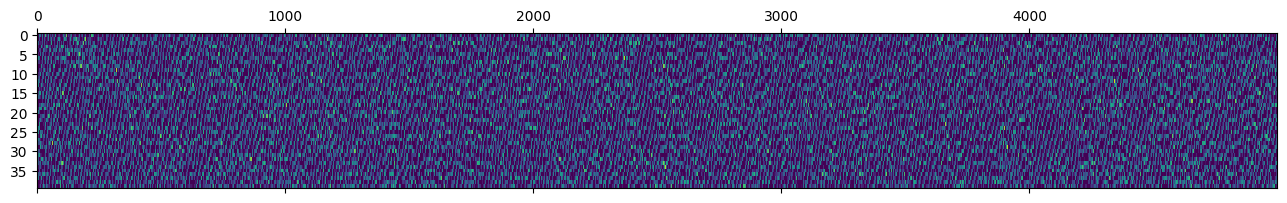

In [2]:
A = np.load('data/Lorenz96/GCp40.npy')
X = np.load('data/Lorenz96/lorenzp40f10_.npy')
X = X.T
plt.matshow(X, aspect='auto',vmin=0)

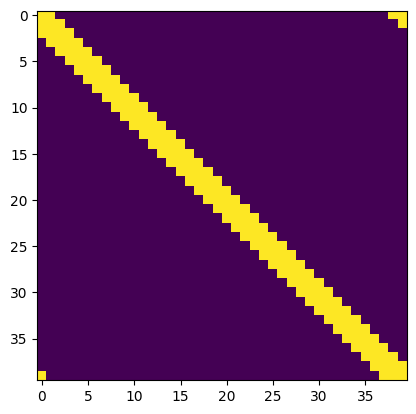

In [3]:
plt.imshow(A!=0)

### Analysis

In [4]:
n_neur,n_perm,N_PASTS = X.shape[0],1000,list(range(1, 3))
alpha, beta = 0, 0 

### With d_CSL algorithm

In [ ]:
infs_fgc = []
conf_mtx_fgc = []
shds_fgc = []
metrics_fgc = []
# for a, n in enumerate(N_PASTS):
for a in range(10):
    print(f'{a}')
    gcstar = GcStar(n_perm = 1000, 
                n_pasts = 1, 
                n_lags = 1,
                temporal = True,
                method = 'fcgc')

    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)
    infs_fgc.append(inf)
    conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A, simulation=False))
    metrics_fgc.append(np.round(gcstar.all_metrics(),4))
    shds_fgc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=False),4))
print('')

0
1
2
3
4
5
6
7
8
9


In [ ]:
fig, axes = plt.subplots(1,len(infs_fgc), figsize=(2.5*len(infs_fgc),3)) 
for i, ax in enumerate(axes):
    ax.imshow(compare_with_GT(A, infs_fgc[i], simulation=False))
    ax.set_title(f'{i+1} pasts')

In [ ]:
print(np.round(metrics_fgc, 4))
print('')
print('')
print(f"SHDs are {shds_fgc}")

In [ ]:
print(np.mean(metrics_fgc, axis=0))
np.round(np.std(metrics_fgc, axis=0),4)

## Granger Causality Adaptation

In [ ]:
infs_gc = []
conf_mtx_gc = []
shds_gc = []
metrics_gc = []
# for a, n in enumerate(N_PASTS):
for a in range(10):
    print(f'{a}')
    gcstar = GcStar(n_perm = 1000,
                n_pasts = 1,
                n_lags = 1,
                temporal = True,
                method = 'cgc')

    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)
    infs_gc.append(inf)
    conf_mtx_gc.append(gcstar.compute_confusion_matrix(A, simulation=False))
    metrics_gc.append(np.round(gcstar.all_metrics(),4))
    shds_gc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=False),4))

In [ ]:
fig, axes = plt.subplots(1,len(infs_gc), figsize=(2.5*len(infs_gc),3))
for i, ax in enumerate(axes):
    ax.imshow(compare_with_GT(A, infs_gc[i], simulation=False))
    ax.set_title(f'{i+1} pasts')

In [ ]:
print(np.round(metrics_gc, 4))
print('')
print('')
print(f"SHDs are {shds_fgc}")

In [ ]:
print(np.mean(metrics_gc, axis=0))
np.round(np.std(metrics_gc, axis=0),4)